In [1]:
from z3 import *
import numpy as np
import random
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.autolayout"] = True # to for tight_layout()
import arviz as az
# our library
from z3 import *
import numpy as np
import re
import arviz as az
import matplotlib.pyplot as plt
import os, sys
from importlib import reload
import pickle as pkl
from datetime import datetime

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(project_root)

import src.sat_metropolis.sat as sat
import src.sat_metropolis.smt as smt
import src.sat_metropolis.mcmc as mcmc
import src.sat_metropolis.utils as utils
import src.sat_metropolis.models as models
# from sat_metropolis import smt, mcmc, sat, utils

reload(sat)
reload(smt)
reload(mcmc)
reload(utils)
reload(models)

<module 'src.sat_metropolis.models' from '/home/kristoffer/ITU/6_semester/linux_bachelor_project/sat-metropolis-businessnisser/src/sat_metropolis/models.py'>

In [2]:
# Taken from (Simson Garfinkel, John M. Abowd, Christian Martindale. Understanding Database Reconstruction Attacks on Public Data. Communications of the ACM, March 2019, Vol. 62 No. 3, Pages 46-53. DOI: 10.1145/3287287)

# Assumption, all bit-vectors are of the same size
num_bits = 8
num_vars = 5*2 # (age, gender)
var_list = [BitVec(f'x{i}',num_bits) for i in range(num_vars)] # 0-4 age vars, 5-9 sex vars
x = var_list
g = Goal()
sat.add_bool_vars_to_goal(g, var_list)
g.add(sat.addition_does_not_overflow([x[0], x[1], x[2], x[3], x[4]]))
g.add(sat.addition_does_not_overflow([x[5], x[6], x[7], x[8], x[9]]))
for i in range(5):
    g.add(sat.multi_does_not_overflow([x[i],x[i+5]])) # this is in case of multiplication

# these are binary (obviously only for the purpose of the example)
# FEMALE = 0
# MALE = 1
for i in range(5,10):
    g.add(ULE(0,x[i]))
    g.add(ULE(x[i],1))


# establish an order to set the median
g.add(ULE(0,x[0]))
g.add(ULE(x[0],x[1]))
g.add(ULE(x[1],x[2]))
g.add(ULE(x[2],x[3]))
g.add(ULE(x[3],x[4]))
g.add(ULE(x[4],125))

g.add(x[2] == 30) # median

g.add(x[0] + x[1] + x[2] + x[3] + x[4] == 38*5) # average age

g.add(x[5] + x[6] + x[7] + x[8] + x[9] == 3) # only 3 males

g.add(x[0]*x[5] + x[1]*x[6] + x[2]*x[7] + x[3]*x[8] + x[4]*x[9] == 44*3) # average age of males

# NOTE: we might need to set an overflow constraint for the last sum.


In [17]:
# trace = sat.get_conditional_incremental_samples_sat_pyunigen_problem_cached(
#     z3_problem=g,
#     num_vars=num_vars,
#     num_bits=num_bits,
#     D=3,
#     num_samples=1,
#     num_iterations=1000,
#     sanity_check_problem=True,
#     print_z3_model=False
# )

variables_number: {1: k!56, 2: x00, 3: k!57, 4: x01, 5: k!58, 6: x02, 7: k!59, 8: x03, 9: k!60, 10: x04, 11: k!61, 12: x05, 13: k!62, 14: x06, 15: k!63, 16: x07, 17: k!64, 18: x10, 19: k!65, 20: x11, 21: k!66, 22: x12, 23: k!67, 24: x13, 25: k!68, 26: x14, 27: k!69, 28: x15, 29: k!70, 30: x16, 31: k!71, 32: x17, 33: k!72, 34: x20, 35: k!73, 36: x21, 37: k!74, 38: x22, 39: k!75, 40: x23, 41: k!76, 42: x24, 43: k!77, 44: x25, 45: k!78, 46: x26, 47: k!79, 48: x27, 49: k!80, 50: x30, 51: k!81, 52: x31, 53: k!82, 54: x32, 55: k!83, 56: x33, 57: k!84, 58: x34, 59: k!85, 60: x35, 61: k!86, 62: x36, 63: k!87, 64: x37, 65: k!88, 66: x40, 67: k!89, 68: x41, 69: k!90, 70: x42, 71: k!91, 72: x43, 73: k!92, 74: x44, 75: k!93, 76: x45, 77: k!94, 78: x46, 79: k!95, 80: x47, 81: k!96, 82: x50, 83: k!97, 84: x51, 85: k!98, 86: x52, 87: k!99, 88: x53, 89: k!100, 90: x54, 91: k!101, 92: x55, 93: k!102, 94: x56, 95: k!103, 96: x57, 97: k!104, 98: x60, 99: k!105, 100: x61, 101: k!106, 102: x62, 103: k!107,

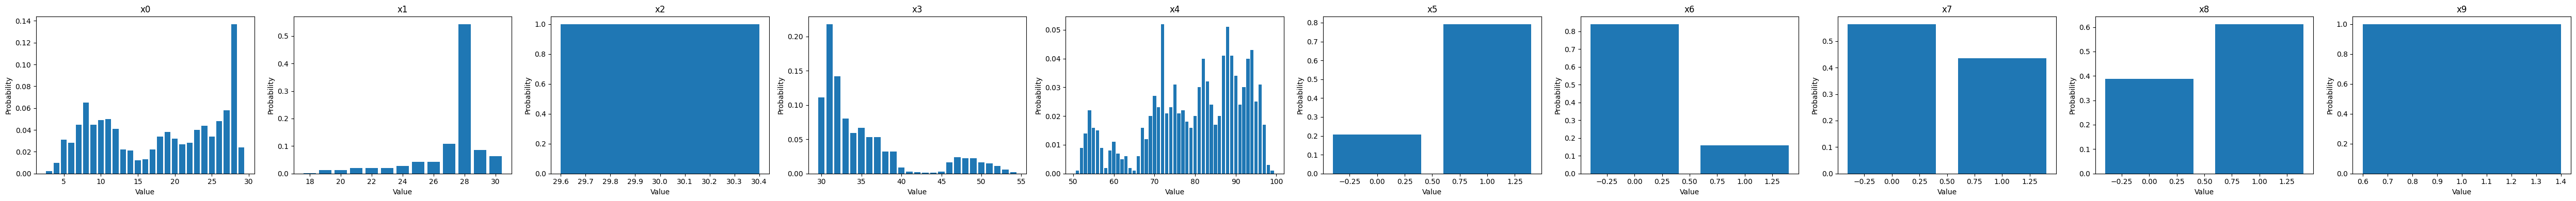

variables_number: {1: k!1635, 2: x00, 3: k!1636, 4: x01, 5: k!1637, 6: x02, 7: k!1638, 8: x03, 9: k!1639, 10: x04, 11: k!1640, 12: x05, 13: k!1641, 14: x06, 15: k!1642, 16: x07, 17: k!1643, 18: x10, 19: k!1644, 20: x11, 21: k!1645, 22: x12, 23: k!1646, 24: x13, 25: k!1647, 26: x14, 27: k!1648, 28: x15, 29: k!1649, 30: x16, 31: k!1650, 32: x17, 33: k!1651, 34: x20, 35: k!1652, 36: x21, 37: k!1653, 38: x22, 39: k!1654, 40: x23, 41: k!1655, 42: x24, 43: k!1656, 44: x25, 45: k!1657, 46: x26, 47: k!1658, 48: x27, 49: k!1659, 50: x30, 51: k!1660, 52: x31, 53: k!1661, 54: x32, 55: k!1662, 56: x33, 57: k!1663, 58: x34, 59: k!1664, 60: x35, 61: k!1665, 62: x36, 63: k!1666, 64: x37, 65: k!1667, 66: x40, 67: k!1668, 68: x41, 69: k!1669, 70: x42, 71: k!1670, 72: x43, 73: k!1671, 74: x44, 75: k!1672, 76: x45, 77: k!1673, 78: x46, 79: k!1674, 80: x47, 81: k!1675, 82: x50, 83: k!1676, 84: x51, 85: k!1677, 86: x52, 87: k!1678, 88: x53, 89: k!1679, 90: x54, 91: k!1680, 92: x55, 93: k!1681, 94: x56, 95:

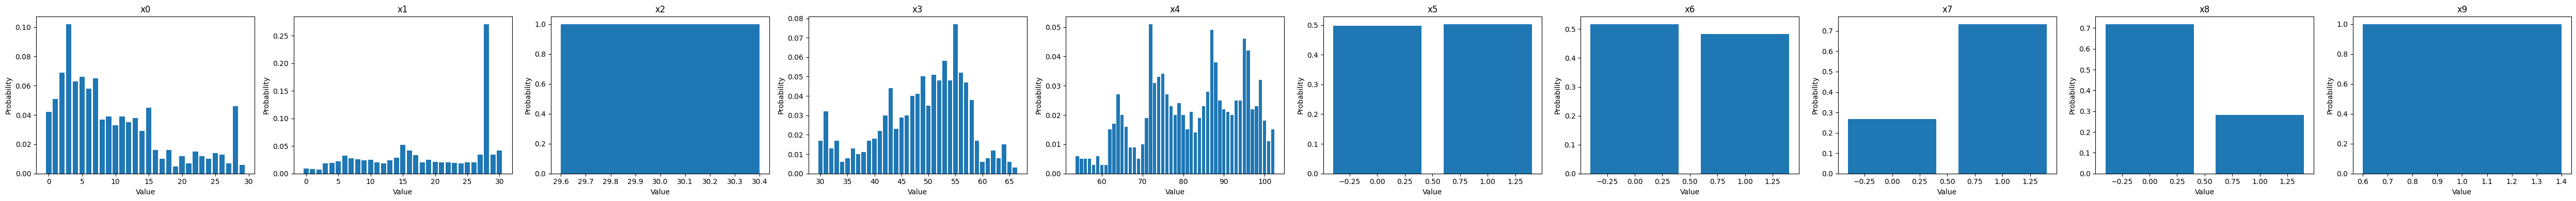

variables_number: {1: k!3197, 2: x00, 3: k!3198, 4: x01, 5: k!3199, 6: x02, 7: k!3200, 8: x03, 9: k!3201, 10: x04, 11: k!3202, 12: x05, 13: k!3203, 14: x06, 15: k!3204, 16: x07, 17: k!3205, 18: x10, 19: k!3206, 20: x11, 21: k!3207, 22: x12, 23: k!3208, 24: x13, 25: k!3209, 26: x14, 27: k!3210, 28: x15, 29: k!3211, 30: x16, 31: k!3212, 32: x17, 33: k!3213, 34: x20, 35: k!3214, 36: x21, 37: k!3215, 38: x22, 39: k!3216, 40: x23, 41: k!3217, 42: x24, 43: k!3218, 44: x25, 45: k!3219, 46: x26, 47: k!3220, 48: x27, 49: k!3221, 50: x30, 51: k!3222, 52: x31, 53: k!3223, 54: x32, 55: k!3224, 56: x33, 57: k!3225, 58: x34, 59: k!3226, 60: x35, 61: k!3227, 62: x36, 63: k!3228, 64: x37, 65: k!3229, 66: x40, 67: k!3230, 68: x41, 69: k!3231, 70: x42, 71: k!3232, 72: x43, 73: k!3233, 74: x44, 75: k!3234, 76: x45, 77: k!3235, 78: x46, 79: k!3236, 80: x47, 81: k!3237, 82: x50, 83: k!3238, 84: x51, 85: k!3239, 86: x52, 87: k!3240, 88: x53, 89: k!3241, 90: x54, 91: k!3242, 92: x55, 93: k!3243, 94: x56, 95:

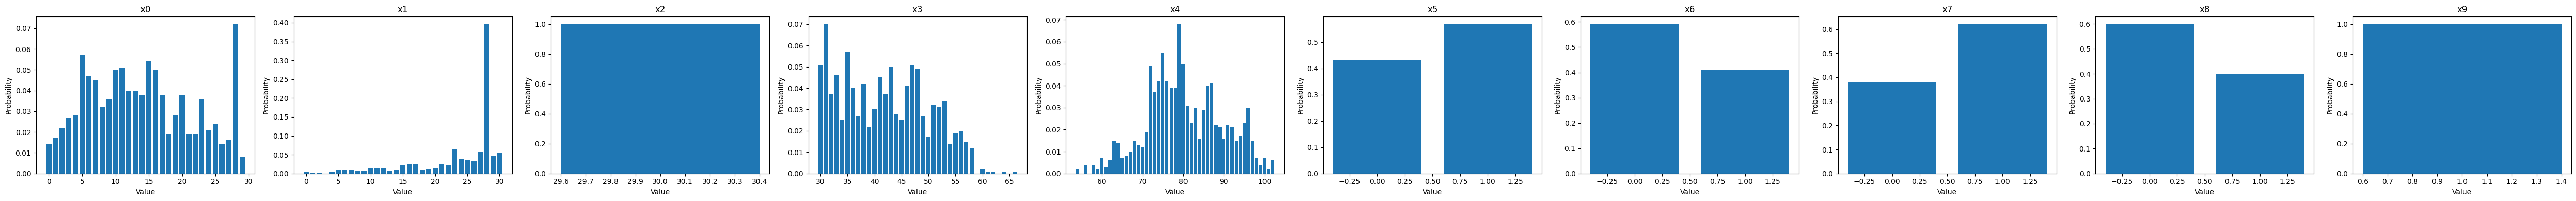

variables_number: {1: k!4754, 2: x00, 3: k!4755, 4: x01, 5: k!4756, 6: x02, 7: k!4757, 8: x03, 9: k!4758, 10: x04, 11: k!4759, 12: x05, 13: k!4760, 14: x06, 15: k!4761, 16: x07, 17: k!4762, 18: x10, 19: k!4763, 20: x11, 21: k!4764, 22: x12, 23: k!4765, 24: x13, 25: k!4766, 26: x14, 27: k!4767, 28: x15, 29: k!4768, 30: x16, 31: k!4769, 32: x17, 33: k!4770, 34: x20, 35: k!4771, 36: x21, 37: k!4772, 38: x22, 39: k!4773, 40: x23, 41: k!4774, 42: x24, 43: k!4775, 44: x25, 45: k!4776, 46: x26, 47: k!4777, 48: x27, 49: k!4778, 50: x30, 51: k!4779, 52: x31, 53: k!4780, 54: x32, 55: k!4781, 56: x33, 57: k!4782, 58: x34, 59: k!4783, 60: x35, 61: k!4784, 62: x36, 63: k!4785, 64: x37, 65: k!4786, 66: x40, 67: k!4787, 68: x41, 69: k!4788, 70: x42, 71: k!4789, 72: x43, 73: k!4790, 74: x44, 75: k!4791, 76: x45, 77: k!4792, 78: x46, 79: k!4793, 80: x47, 81: k!4794, 82: x50, 83: k!4795, 84: x51, 85: k!4796, 86: x52, 87: k!4797, 88: x53, 89: k!4798, 90: x54, 91: k!4799, 92: x55, 93: k!4800, 94: x56, 95:

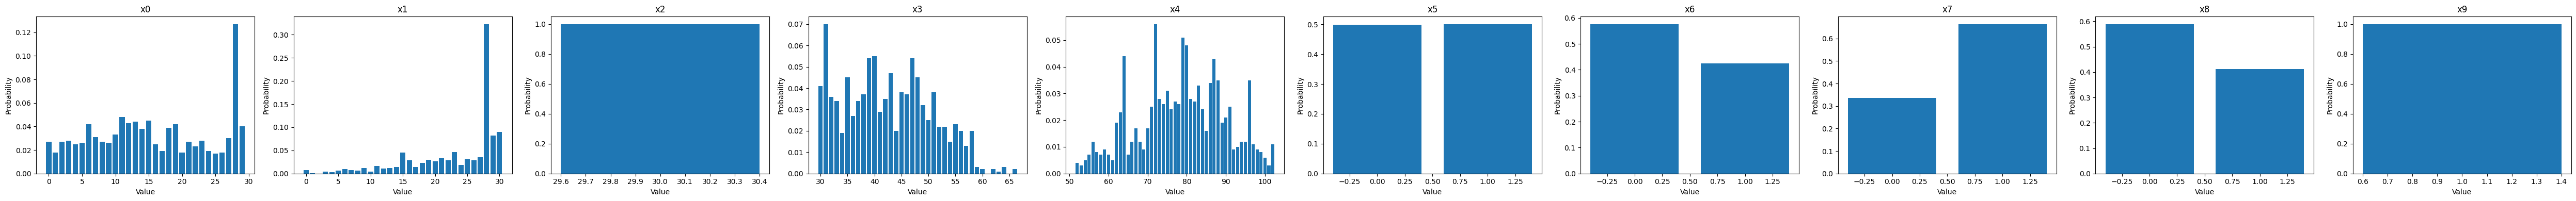

variables_number: {1: k!6320, 2: x00, 3: k!6321, 4: x01, 5: k!6322, 6: x02, 7: k!6323, 8: x03, 9: k!6324, 10: x04, 11: k!6325, 12: x05, 13: k!6326, 14: x06, 15: k!6327, 16: x07, 17: k!6328, 18: x10, 19: k!6329, 20: x11, 21: k!6330, 22: x12, 23: k!6331, 24: x13, 25: k!6332, 26: x14, 27: k!6333, 28: x15, 29: k!6334, 30: x16, 31: k!6335, 32: x17, 33: k!6336, 34: x20, 35: k!6337, 36: x21, 37: k!6338, 38: x22, 39: k!6339, 40: x23, 41: k!6340, 42: x24, 43: k!6341, 44: x25, 45: k!6342, 46: x26, 47: k!6343, 48: x27, 49: k!6344, 50: x30, 51: k!6345, 52: x31, 53: k!6346, 54: x32, 55: k!6347, 56: x33, 57: k!6348, 58: x34, 59: k!6349, 60: x35, 61: k!6350, 62: x36, 63: k!6351, 64: x37, 65: k!6352, 66: x40, 67: k!6353, 68: x41, 69: k!6354, 70: x42, 71: k!6355, 72: x43, 73: k!6356, 74: x44, 75: k!6357, 76: x45, 77: k!6358, 78: x46, 79: k!6359, 80: x47, 81: k!6360, 82: x50, 83: k!6361, 84: x51, 85: k!6362, 86: x52, 87: k!6363, 88: x53, 89: k!6364, 90: x54, 91: k!6365, 92: x55, 93: k!6366, 94: x56, 95:

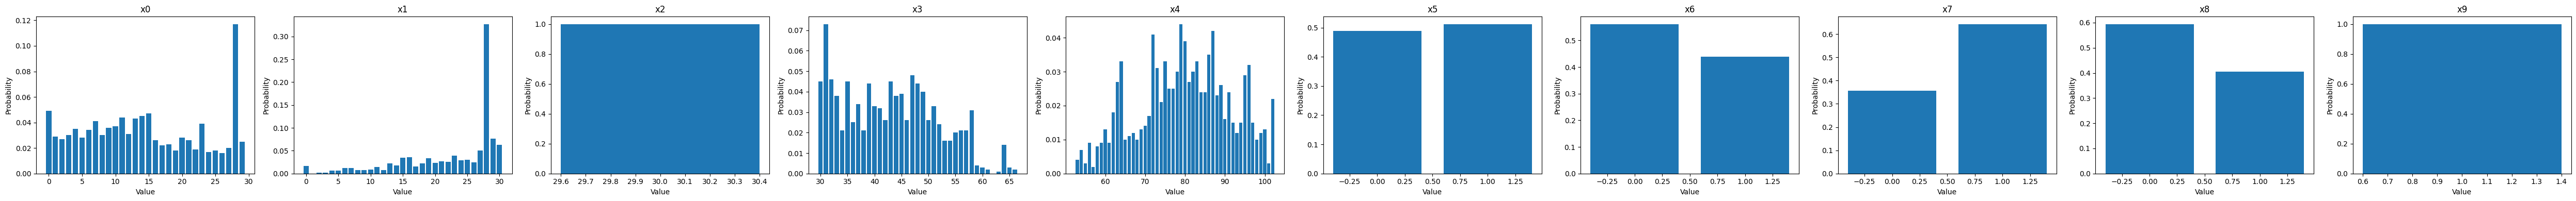

variables_number: {1: k!7883, 2: x00, 3: k!7884, 4: x01, 5: k!7885, 6: x02, 7: k!7886, 8: x03, 9: k!7887, 10: x04, 11: k!7888, 12: x05, 13: k!7889, 14: x06, 15: k!7890, 16: x07, 17: k!7891, 18: x10, 19: k!7892, 20: x11, 21: k!7893, 22: x12, 23: k!7894, 24: x13, 25: k!7895, 26: x14, 27: k!7896, 28: x15, 29: k!7897, 30: x16, 31: k!7898, 32: x17, 33: k!7899, 34: x20, 35: k!7900, 36: x21, 37: k!7901, 38: x22, 39: k!7902, 40: x23, 41: k!7903, 42: x24, 43: k!7904, 44: x25, 45: k!7905, 46: x26, 47: k!7906, 48: x27, 49: k!7907, 50: x30, 51: k!7908, 52: x31, 53: k!7909, 54: x32, 55: k!7910, 56: x33, 57: k!7911, 58: x34, 59: k!7912, 60: x35, 61: k!7913, 62: x36, 63: k!7914, 64: x37, 65: k!7915, 66: x40, 67: k!7916, 68: x41, 69: k!7917, 70: x42, 71: k!7918, 72: x43, 73: k!7919, 74: x44, 75: k!7920, 76: x45, 77: k!7921, 78: x46, 79: k!7922, 80: x47, 81: k!7923, 82: x50, 83: k!7924, 84: x51, 85: k!7925, 86: x52, 87: k!7926, 88: x53, 89: k!7927, 90: x54, 91: k!7928, 92: x55, 93: k!7929, 94: x56, 95:

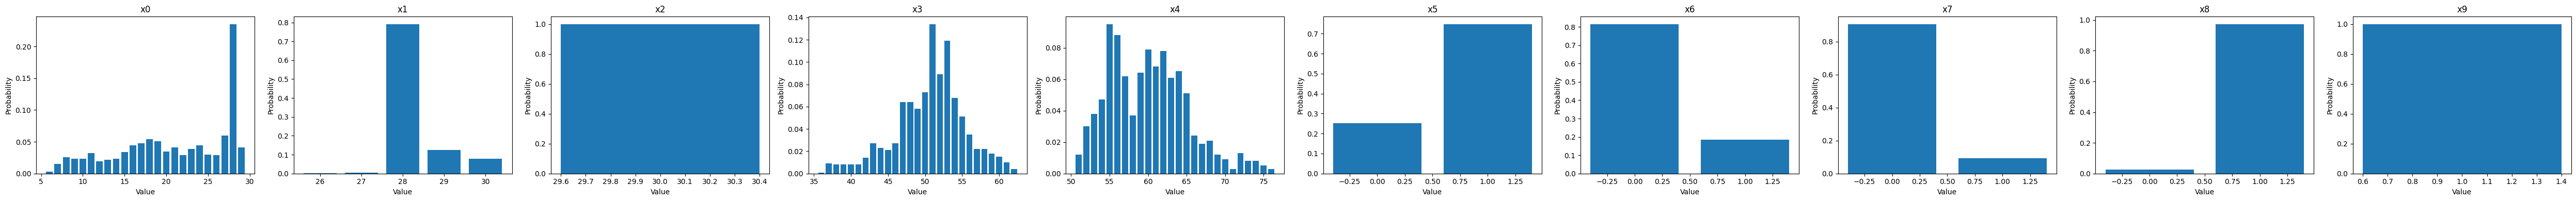

variables_number: {1: k!9467, 2: x00, 3: k!9468, 4: x01, 5: k!9469, 6: x02, 7: k!9470, 8: x03, 9: k!9471, 10: x04, 11: k!9472, 12: x05, 13: k!9473, 14: x06, 15: k!9474, 16: x07, 17: k!9475, 18: x10, 19: k!9476, 20: x11, 21: k!9477, 22: x12, 23: k!9478, 24: x13, 25: k!9479, 26: x14, 27: k!9480, 28: x15, 29: k!9481, 30: x16, 31: k!9482, 32: x17, 33: k!9483, 34: x20, 35: k!9484, 36: x21, 37: k!9485, 38: x22, 39: k!9486, 40: x23, 41: k!9487, 42: x24, 43: k!9488, 44: x25, 45: k!9489, 46: x26, 47: k!9490, 48: x27, 49: k!9491, 50: x30, 51: k!9492, 52: x31, 53: k!9493, 54: x32, 55: k!9494, 56: x33, 57: k!9495, 58: x34, 59: k!9496, 60: x35, 61: k!9497, 62: x36, 63: k!9498, 64: x37, 65: k!9499, 66: x40, 67: k!9500, 68: x41, 69: k!9501, 70: x42, 71: k!9502, 72: x43, 73: k!9503, 74: x44, 75: k!9504, 76: x45, 77: k!9505, 78: x46, 79: k!9506, 80: x47, 81: k!9507, 82: x50, 83: k!9508, 84: x51, 85: k!9509, 86: x52, 87: k!9510, 88: x53, 89: k!9511, 90: x54, 91: k!9512, 92: x55, 93: k!9513, 94: x56, 95:

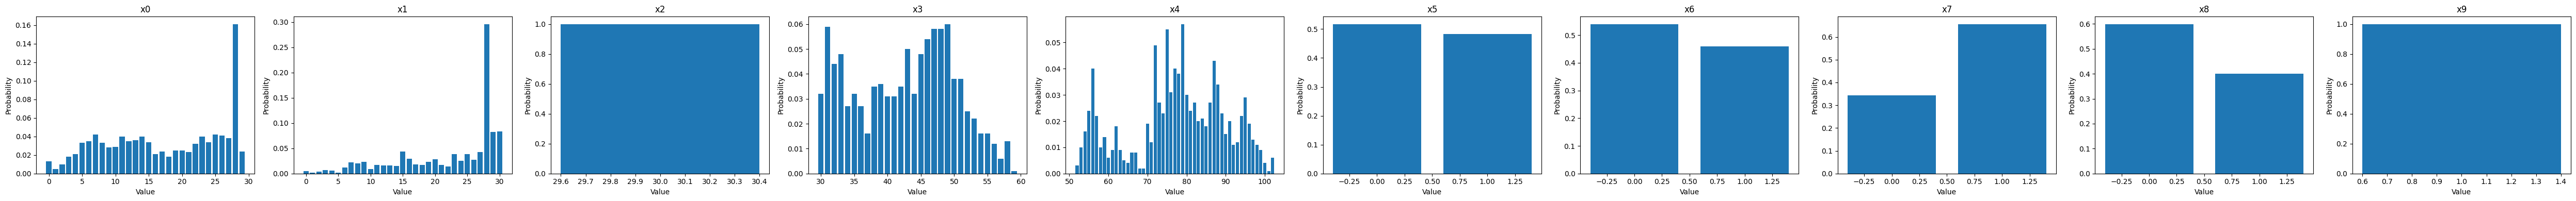

variables_number: {1: k!11060, 2: x00, 3: k!11061, 4: x01, 5: k!11062, 6: x02, 7: k!11063, 8: x03, 9: k!11064, 10: x04, 11: k!11065, 12: x05, 13: k!11066, 14: x06, 15: k!11067, 16: x07, 17: k!11068, 18: x10, 19: k!11069, 20: x11, 21: k!11070, 22: x12, 23: k!11071, 24: x13, 25: k!11072, 26: x14, 27: k!11073, 28: x15, 29: k!11074, 30: x16, 31: k!11075, 32: x17, 33: k!11076, 34: x20, 35: k!11077, 36: x21, 37: k!11078, 38: x22, 39: k!11079, 40: x23, 41: k!11080, 42: x24, 43: k!11081, 44: x25, 45: k!11082, 46: x26, 47: k!11083, 48: x27, 49: k!11084, 50: x30, 51: k!11085, 52: x31, 53: k!11086, 54: x32, 55: k!11087, 56: x33, 57: k!11088, 58: x34, 59: k!11089, 60: x35, 61: k!11090, 62: x36, 63: k!11091, 64: x37, 65: k!11092, 66: x40, 67: k!11093, 68: x41, 69: k!11094, 70: x42, 71: k!11095, 72: x43, 73: k!11096, 74: x44, 75: k!11097, 76: x45, 77: k!11098, 78: x46, 79: k!11099, 80: x47, 81: k!11100, 82: x50, 83: k!11101, 84: x51, 85: k!11102, 86: x52, 87: k!11103, 88: x53, 89: k!11104, 90: x54, 

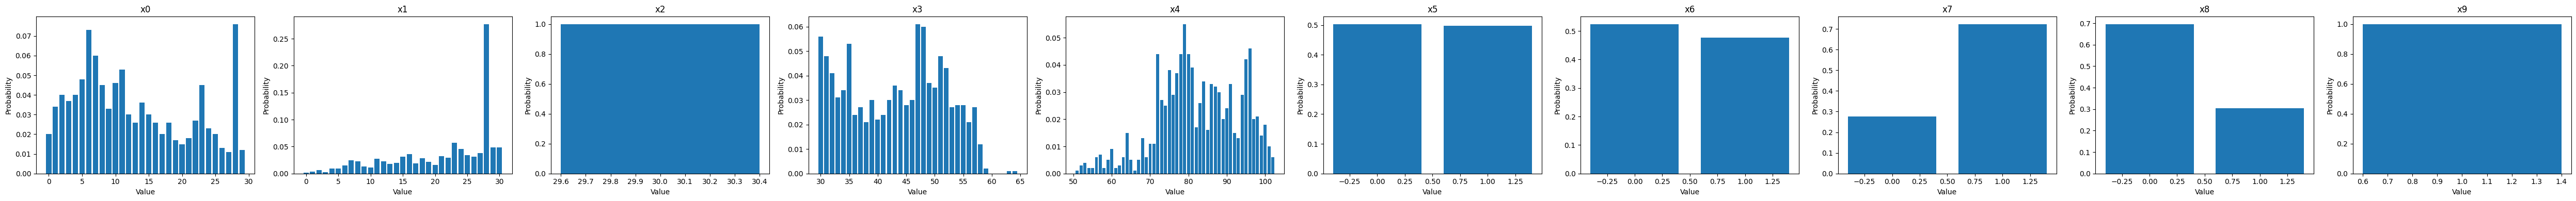

variables_number: {1: k!12599, 2: x00, 3: k!12600, 4: x01, 5: k!12601, 6: x02, 7: k!12602, 8: x03, 9: k!12603, 10: x04, 11: k!12604, 12: x05, 13: k!12605, 14: x06, 15: k!12606, 16: x07, 17: k!12607, 18: x10, 19: k!12608, 20: x11, 21: k!12609, 22: x12, 23: k!12610, 24: x13, 25: k!12611, 26: x14, 27: k!12612, 28: x15, 29: k!12613, 30: x16, 31: k!12614, 32: x17, 33: k!12615, 34: x20, 35: k!12616, 36: x21, 37: k!12617, 38: x22, 39: k!12618, 40: x23, 41: k!12619, 42: x24, 43: k!12620, 44: x25, 45: k!12621, 46: x26, 47: k!12622, 48: x27, 49: k!12623, 50: x30, 51: k!12624, 52: x31, 53: k!12625, 54: x32, 55: k!12626, 56: x33, 57: k!12627, 58: x34, 59: k!12628, 60: x35, 61: k!12629, 62: x36, 63: k!12630, 64: x37, 65: k!12631, 66: x40, 67: k!12632, 68: x41, 69: k!12633, 70: x42, 71: k!12634, 72: x43, 73: k!12635, 74: x44, 75: k!12636, 76: x45, 77: k!12637, 78: x46, 79: k!12638, 80: x47, 81: k!12639, 82: x50, 83: k!12640, 84: x51, 85: k!12641, 86: x52, 87: k!12642, 88: x53, 89: k!12643, 90: x54, 

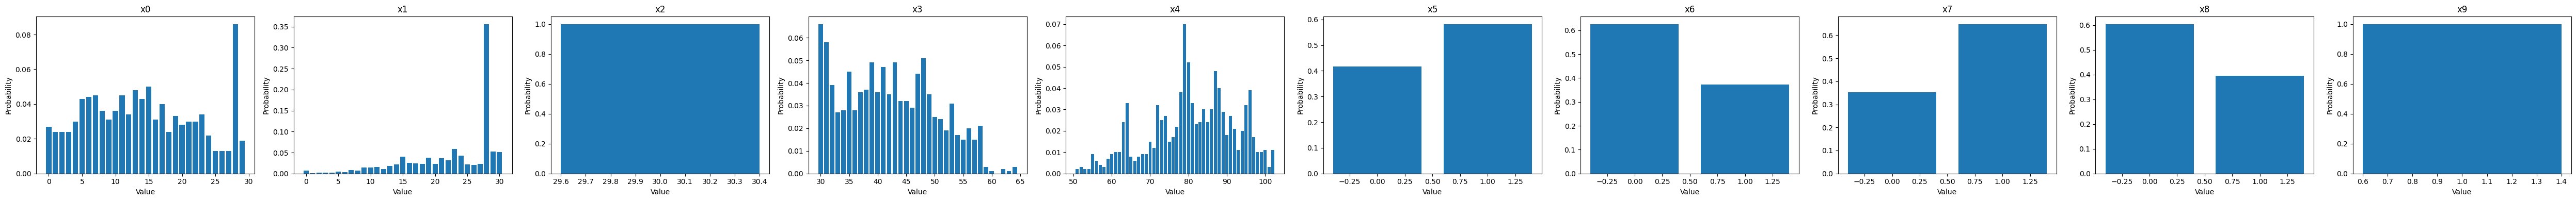

variables_number: {1: k!14174, 2: x00, 3: k!14175, 4: x01, 5: k!14176, 6: x02, 7: k!14177, 8: x03, 9: k!14178, 10: x04, 11: k!14179, 12: x05, 13: k!14180, 14: x06, 15: k!14181, 16: x07, 17: k!14182, 18: x10, 19: k!14183, 20: x11, 21: k!14184, 22: x12, 23: k!14185, 24: x13, 25: k!14186, 26: x14, 27: k!14187, 28: x15, 29: k!14188, 30: x16, 31: k!14189, 32: x17, 33: k!14190, 34: x20, 35: k!14191, 36: x21, 37: k!14192, 38: x22, 39: k!14193, 40: x23, 41: k!14194, 42: x24, 43: k!14195, 44: x25, 45: k!14196, 46: x26, 47: k!14197, 48: x27, 49: k!14198, 50: x30, 51: k!14199, 52: x31, 53: k!14200, 54: x32, 55: k!14201, 56: x33, 57: k!14202, 58: x34, 59: k!14203, 60: x35, 61: k!14204, 62: x36, 63: k!14205, 64: x37, 65: k!14206, 66: x40, 67: k!14207, 68: x41, 69: k!14208, 70: x42, 71: k!14209, 72: x43, 73: k!14210, 74: x44, 75: k!14211, 76: x45, 77: k!14212, 78: x46, 79: k!14213, 80: x47, 81: k!14214, 82: x50, 83: k!14215, 84: x51, 85: k!14216, 86: x52, 87: k!14217, 88: x53, 89: k!14218, 90: x54, 

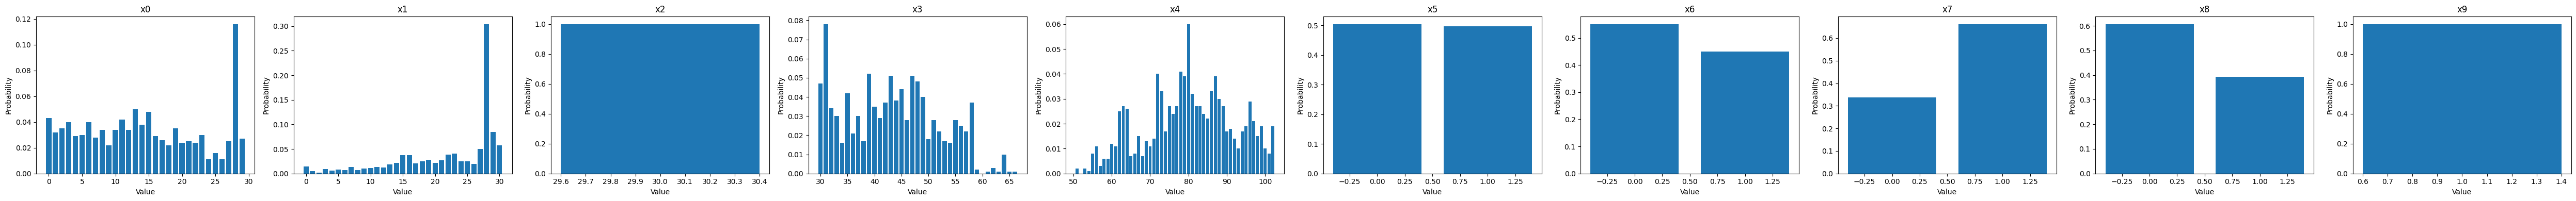

variables_number: {1: k!15757, 2: x00, 3: k!15758, 4: x01, 5: k!15759, 6: x02, 7: k!15760, 8: x03, 9: k!15761, 10: x04, 11: k!15762, 12: x05, 13: k!15763, 14: x06, 15: k!15764, 16: x07, 17: k!15765, 18: x10, 19: k!15766, 20: x11, 21: k!15767, 22: x12, 23: k!15768, 24: x13, 25: k!15769, 26: x14, 27: k!15770, 28: x15, 29: k!15771, 30: x16, 31: k!15772, 32: x17, 33: k!15773, 34: x20, 35: k!15774, 36: x21, 37: k!15775, 38: x22, 39: k!15776, 40: x23, 41: k!15777, 42: x24, 43: k!15778, 44: x25, 45: k!15779, 46: x26, 47: k!15780, 48: x27, 49: k!15781, 50: x30, 51: k!15782, 52: x31, 53: k!15783, 54: x32, 55: k!15784, 56: x33, 57: k!15785, 58: x34, 59: k!15786, 60: x35, 61: k!15787, 62: x36, 63: k!15788, 64: x37, 65: k!15789, 66: x40, 67: k!15790, 68: x41, 69: k!15791, 70: x42, 71: k!15792, 72: x43, 73: k!15793, 74: x44, 75: k!15794, 76: x45, 77: k!15795, 78: x46, 79: k!15796, 80: x47, 81: k!15797, 82: x50, 83: k!15798, 84: x51, 85: k!15799, 86: x52, 87: k!15800, 88: x53, 89: k!15801, 90: x54, 

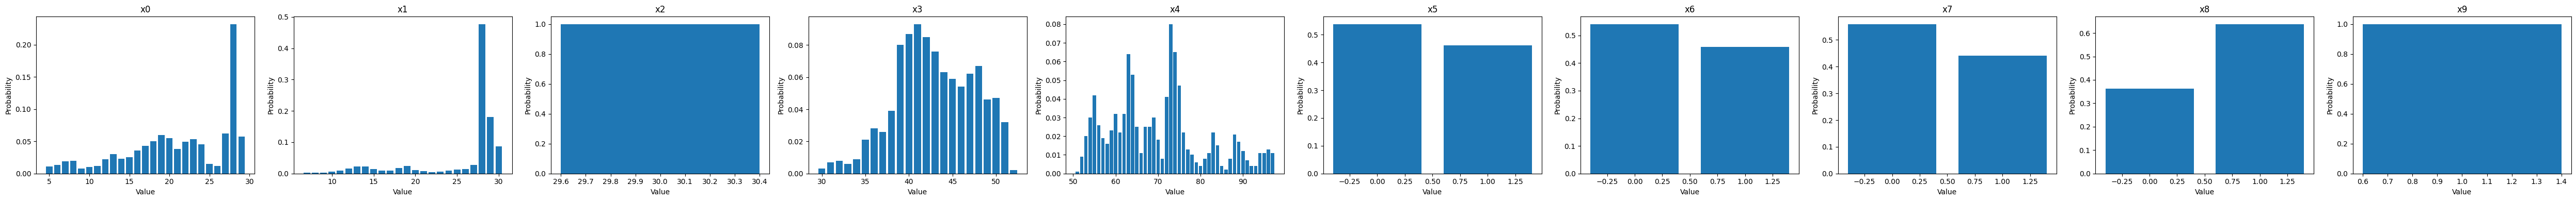

variables_number: {1: k!17335, 2: x00, 3: k!17336, 4: x01, 5: k!17337, 6: x02, 7: k!17338, 8: x03, 9: k!17339, 10: x04, 11: k!17340, 12: x05, 13: k!17341, 14: x06, 15: k!17342, 16: x07, 17: k!17343, 18: x10, 19: k!17344, 20: x11, 21: k!17345, 22: x12, 23: k!17346, 24: x13, 25: k!17347, 26: x14, 27: k!17348, 28: x15, 29: k!17349, 30: x16, 31: k!17350, 32: x17, 33: k!17351, 34: x20, 35: k!17352, 36: x21, 37: k!17353, 38: x22, 39: k!17354, 40: x23, 41: k!17355, 42: x24, 43: k!17356, 44: x25, 45: k!17357, 46: x26, 47: k!17358, 48: x27, 49: k!17359, 50: x30, 51: k!17360, 52: x31, 53: k!17361, 54: x32, 55: k!17362, 56: x33, 57: k!17363, 58: x34, 59: k!17364, 60: x35, 61: k!17365, 62: x36, 63: k!17366, 64: x37, 65: k!17367, 66: x40, 67: k!17368, 68: x41, 69: k!17369, 70: x42, 71: k!17370, 72: x43, 73: k!17371, 74: x44, 75: k!17372, 76: x45, 77: k!17373, 78: x46, 79: k!17374, 80: x47, 81: k!17375, 82: x50, 83: k!17376, 84: x51, 85: k!17377, 86: x52, 87: k!17378, 88: x53, 89: k!17379, 90: x54, 

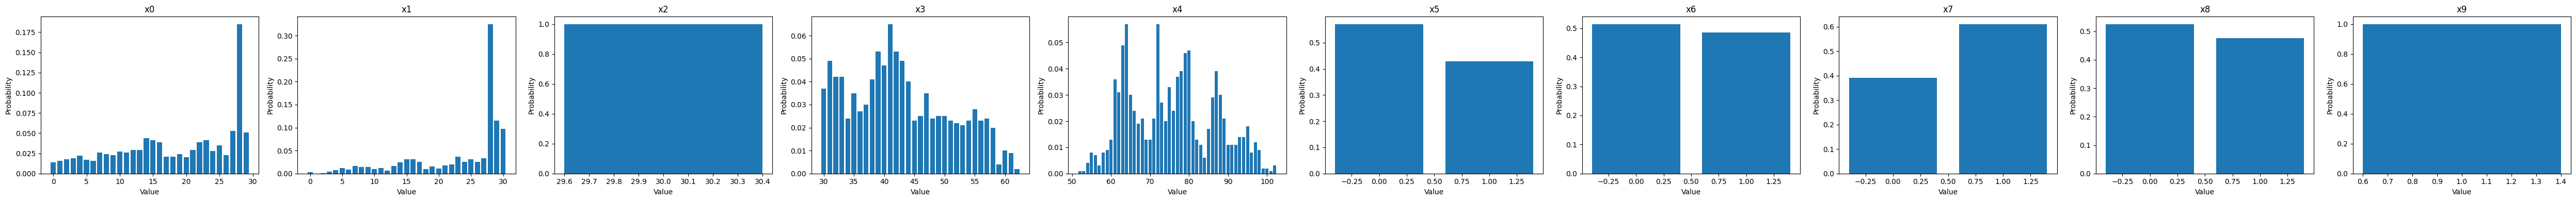

variables_number: {1: k!18890, 2: x00, 3: k!18891, 4: x01, 5: k!18892, 6: x02, 7: k!18893, 8: x03, 9: k!18894, 10: x04, 11: k!18895, 12: x05, 13: k!18896, 14: x06, 15: k!18897, 16: x07, 17: k!18898, 18: x10, 19: k!18899, 20: x11, 21: k!18900, 22: x12, 23: k!18901, 24: x13, 25: k!18902, 26: x14, 27: k!18903, 28: x15, 29: k!18904, 30: x16, 31: k!18905, 32: x17, 33: k!18906, 34: x20, 35: k!18907, 36: x21, 37: k!18908, 38: x22, 39: k!18909, 40: x23, 41: k!18910, 42: x24, 43: k!18911, 44: x25, 45: k!18912, 46: x26, 47: k!18913, 48: x27, 49: k!18914, 50: x30, 51: k!18915, 52: x31, 53: k!18916, 54: x32, 55: k!18917, 56: x33, 57: k!18918, 58: x34, 59: k!18919, 60: x35, 61: k!18920, 62: x36, 63: k!18921, 64: x37, 65: k!18922, 66: x40, 67: k!18923, 68: x41, 69: k!18924, 70: x42, 71: k!18925, 72: x43, 73: k!18926, 74: x44, 75: k!18927, 76: x45, 77: k!18928, 78: x46, 79: k!18929, 80: x47, 81: k!18930, 82: x50, 83: k!18931, 84: x51, 85: k!18932, 86: x52, 87: k!18933, 88: x53, 89: k!18934, 90: x54, 

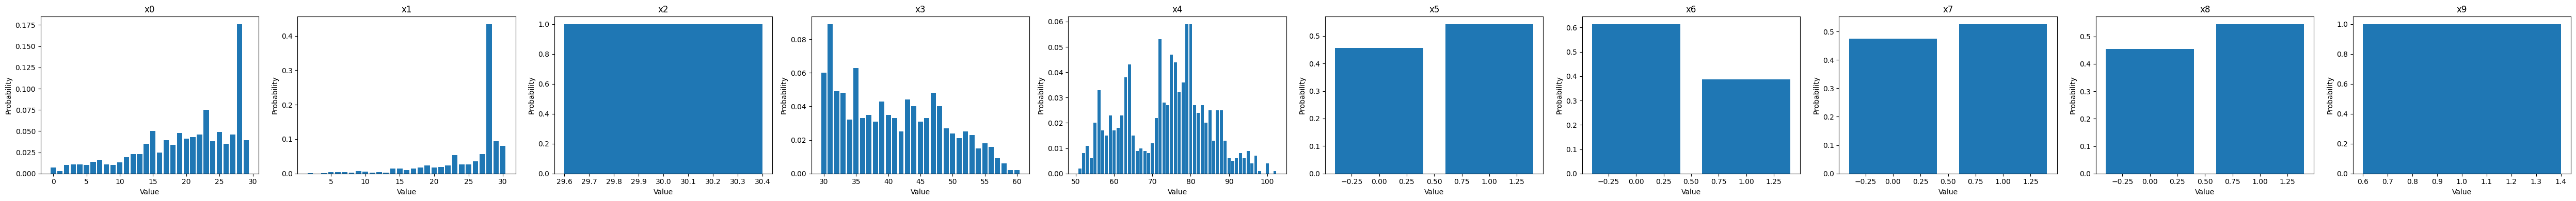

variables_number: {1: k!20446, 2: x00, 3: k!20447, 4: x01, 5: k!20448, 6: x02, 7: k!20449, 8: x03, 9: k!20450, 10: x04, 11: k!20451, 12: x05, 13: k!20452, 14: x06, 15: k!20453, 16: x07, 17: k!20454, 18: x10, 19: k!20455, 20: x11, 21: k!20456, 22: x12, 23: k!20457, 24: x13, 25: k!20458, 26: x14, 27: k!20459, 28: x15, 29: k!20460, 30: x16, 31: k!20461, 32: x17, 33: k!20462, 34: x20, 35: k!20463, 36: x21, 37: k!20464, 38: x22, 39: k!20465, 40: x23, 41: k!20466, 42: x24, 43: k!20467, 44: x25, 45: k!20468, 46: x26, 47: k!20469, 48: x27, 49: k!20470, 50: x30, 51: k!20471, 52: x31, 53: k!20472, 54: x32, 55: k!20473, 56: x33, 57: k!20474, 58: x34, 59: k!20475, 60: x35, 61: k!20476, 62: x36, 63: k!20477, 64: x37, 65: k!20478, 66: x40, 67: k!20479, 68: x41, 69: k!20480, 70: x42, 71: k!20481, 72: x43, 73: k!20482, 74: x44, 75: k!20483, 76: x45, 77: k!20484, 78: x46, 79: k!20485, 80: x47, 81: k!20486, 82: x50, 83: k!20487, 84: x51, 85: k!20488, 86: x52, 87: k!20489, 88: x53, 89: k!20490, 90: x54, 

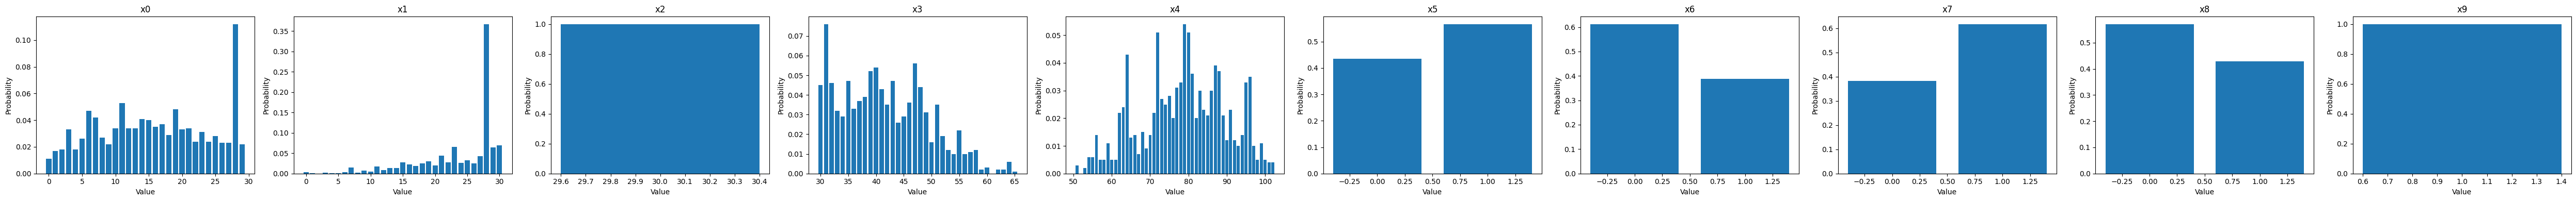

variables_number: {1: k!22012, 2: x00, 3: k!22013, 4: x01, 5: k!22014, 6: x02, 7: k!22015, 8: x03, 9: k!22016, 10: x04, 11: k!22017, 12: x05, 13: k!22018, 14: x06, 15: k!22019, 16: x07, 17: k!22020, 18: x10, 19: k!22021, 20: x11, 21: k!22022, 22: x12, 23: k!22023, 24: x13, 25: k!22024, 26: x14, 27: k!22025, 28: x15, 29: k!22026, 30: x16, 31: k!22027, 32: x17, 33: k!22028, 34: x20, 35: k!22029, 36: x21, 37: k!22030, 38: x22, 39: k!22031, 40: x23, 41: k!22032, 42: x24, 43: k!22033, 44: x25, 45: k!22034, 46: x26, 47: k!22035, 48: x27, 49: k!22036, 50: x30, 51: k!22037, 52: x31, 53: k!22038, 54: x32, 55: k!22039, 56: x33, 57: k!22040, 58: x34, 59: k!22041, 60: x35, 61: k!22042, 62: x36, 63: k!22043, 64: x37, 65: k!22044, 66: x40, 67: k!22045, 68: x41, 69: k!22046, 70: x42, 71: k!22047, 72: x43, 73: k!22048, 74: x44, 75: k!22049, 76: x45, 77: k!22050, 78: x46, 79: k!22051, 80: x47, 81: k!22052, 82: x50, 83: k!22053, 84: x51, 85: k!22054, 86: x52, 87: k!22055, 88: x53, 89: k!22056, 90: x54, 

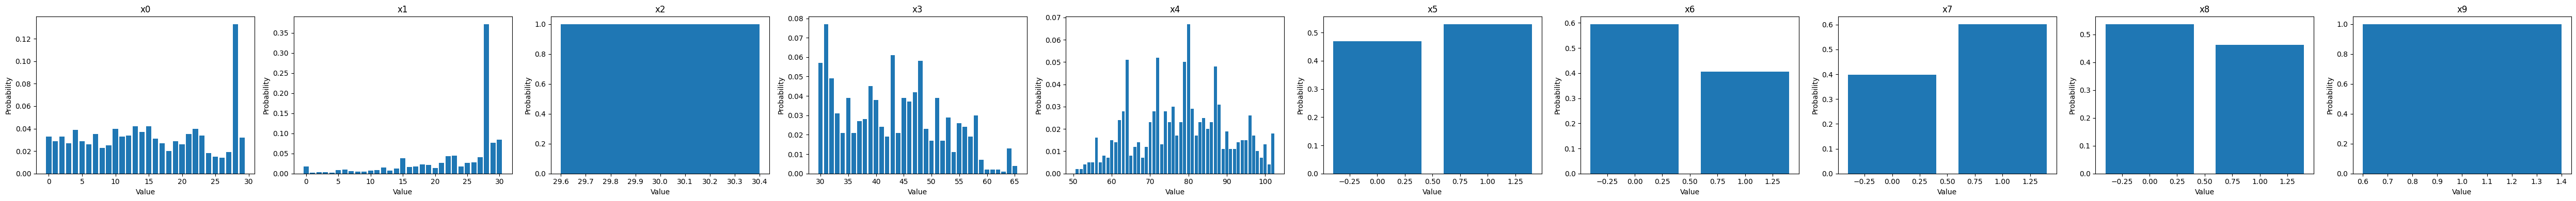

In [4]:
ds = [1,3,5,10,20]
samples = 1000
backend = "pycmsgen"
current_time = datetime.now()
formatted = (
    f"y{current_time.year}"
    f"m{current_time.month:02d}"
    f"d{current_time.day:02d}"
    f"h{current_time.hour:02d}"
    f"m{current_time.minute:02d}"
    f"s{current_time.second:02d}"
)
for k in range(3):
    for i in range(len(ds)):
        trace = mcmc.sample_mh_trace_from_z3_model(
            method = "incremental",
            backend=backend,
            z3_problem=g,
            D=ds[i],
            num_vars=num_vars,
            num_bits=num_bits,
            parallel_samples=1,
            time_tracking= True,
            num_samples=samples,
            print_z3_model=False
        )
        
        az.to_netcdf(trace[0], f'{project_root}/experiments/traces/d_tests/trace_db_cacm_{samples}_{backend}_{k+1}_d{ds[i]}_{formatted}.nc')
        with open(f'{project_root}/experiments/traces/d_tests/trace_db_cacm_{samples}_{backend}_{k+1}_d{ds[i]}_with_timetracking_{formatted}.pkl', "wb") as f:
            pkl.dump(trace[1], f)
        
        


In [10]:
# trace = mcmc.sample_mh_trace_from_z3_model(backend='unigen',
#                                            z3_problem=g,
#                                            num_vars=num_vars,
#                                            num_bits=num_bits,
#                                            timeout_sampler=3600,
#                                            num_samples=5000,
#                                            num_chains=10)

In [19]:
trace

Inference data with groups:
	> posterior

In [20]:
from collections import Counter
import matplotlib.pyplot as plt
import math

def plot_distributions(samples):
    keys = list(samples[0].keys())
    n = len(keys)

    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for ax, key in zip(axes, keys):
        vals = [d[key] for d in samples]
        c = Counter(vals)

        xs = sorted(c.keys())
        total = sum(c.values())
        ys = [c[x] / total for x in xs]

        ax.bar(xs, ys)
        ax.set_title(key)
        ax.set_xlabel("Value")
        ax.set_ylabel("Probability")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

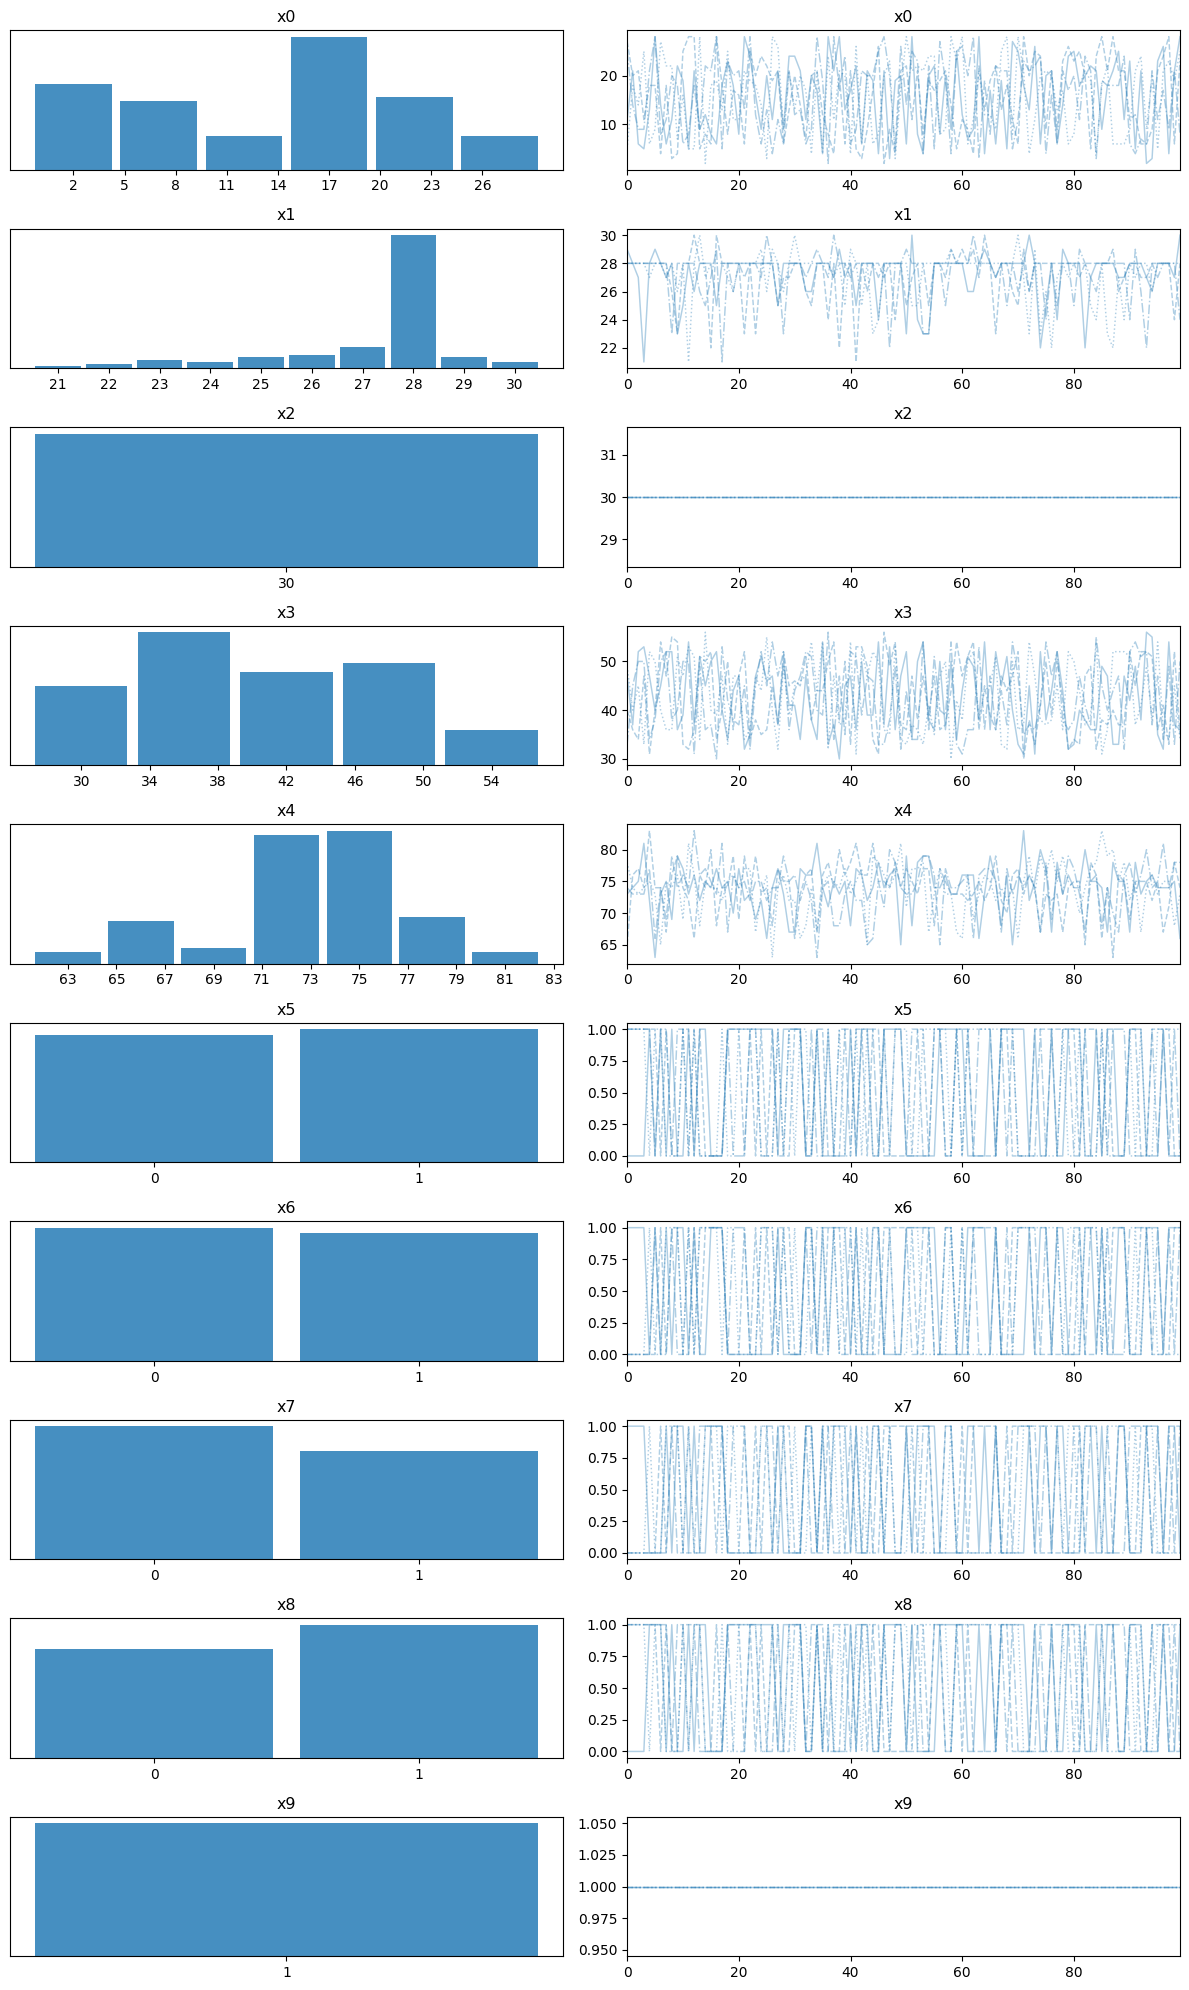

In [23]:
# Trace plot
az.plot_trace(trace);
plt.savefig('unigen_trace_plot.png', dpi=15);

In [14]:
# Diagnosis
az.summary(trace)

/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,15.88,7.775,4.0,28.0,0.347,0.163,487.0,400.0,1.00
x1,27.23,1.751,22.0,29.0,0.086,0.098,496.0,376.0,1.00
x2,30.00,0.000,30.0,30.0,0.000,NaN,400.0,400.0,NaN
x3,42.93,7.419,32.0,54.0,0.332,0.138,490.0,340.0,0.99
x4,73.96,3.914,65.0,80.0,0.194,0.123,342.0,362.0,1.00
x5,0.51,0.501,0.0,1.0,0.026,0.001,368.0,368.0,0.99
x6,0.49,0.501,0.0,1.0,0.026,0.001,368.0,368.0,0.99
x7,0.45,0.498,0.0,1.0,0.027,0.003,339.0,339.0,0.99
x8,0.55,0.498,0.0,1.0,0.027,0.003,339.0,339.0,0.99
x9,1.00,0.000,1.0,1.0,0.000,NaN,400.0,400.0,NaN


In [15]:
utils.save_trace(trace, f'db_cacm_SAT_inc_pyunigen_{num_vars}_{num_bits}.nc')

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) ANALYTICAL SOLUTION
# ============================================================

# list all ages with required median and average age
avg_sat = [
    (x0, x1, 30, x3, x4)
    for x0 in range(31)
    for x1 in range(31)
    for x3 in range(30, 126)
    for x4 in range(30, 126)
    if x0 + x1 + 30 + x3 + x4 == 38 * 5
    and x0 <= x1 <= 30 <= x3 <= x4
]

# list all genders with exactly 3 males
g_sat = [
    (g0, g1, g2, g3, g4)
    for g0 in range(2)
    for g1 in range(2)
    for g2 in range(2)
    for g3 in range(2)
    for g4 in range(2)
    if g0 + g1 + g2 + g3 + g4 == 3
]

# keep only entries with the required average for males
sat_models = [
    ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4))
    for (x0, x1, x2, x3, x4) in avg_sat
    for (g0, g1, g2, g3, g4) in g_sat
    if x0 * g0 + x1 * g1 + x2 * g2 + x3 * g3 + x4 * g4 == 44 * 3
]

# prior on each variable type
p_x01 = lambda x: 1 / 31
p_x2 = lambda x: 1
p_x34 = lambda x: 1 / 96
p_g = lambda x: 1 / 2

# compute unnormalized posterior probabilities
unnormalized_probs = np.array([
    p_x01(x0) * p_x01(x1) * p_x2(x2) * p_x34(x3) * p_x34(x4)
    * p_g(g0) * p_g(g1) * p_g(g2) * p_g(g3) * p_g(g4)
    for ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)) in sat_models
])

# compute total probability mass (normalizing factor)
total_prob = unnormalized_probs.sum()

# normalized probabilities
normalized_probs = unnormalized_probs / total_prob

# put everything in a dataframe
d = {
    'x0': [], 'x1': [], 'x2': [], 'x3': [], 'x4': [],
    'g0': [], 'g1': [], 'g2': [], 'g3': [], 'g4': [],
    'p': []
}

for (((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)), p) in zip(sat_models, normalized_probs):
    d['x0'].append(x0)
    d['x1'].append(x1)
    d['x2'].append(x2)
    d['x3'].append(x3)
    d['x4'].append(x4)
    d['g0'].append(g0)
    d['g1'].append(g1)
    d['g2'].append(g2)
    d['g3'].append(g3)
    d['g4'].append(g4)
    d['p'].append(p)

df = pd.DataFrame(d)

# exact analytical marginal probability
def p_var(var_name, outcome):
    return df.loc[df[var_name] == outcome, 'p'].sum()

# ============================================================
# 2) SINGLE TRACE VS ANALYTICAL SOLUTION
# ============================================================
# Assumes:
#   - `trace` is one ArviZ InferenceData object
#   - trace.posterior contains x0, x1, ..., x9
#
# Mapping:
#   x0..x4  -> exact vars x0..x4
#   x5..x9  -> exact vars g0..g4

def p_est_single(trace, var_name, outcome):
    vals = trace.posterior[var_name].values.reshape(-1)
    return np.mean(vals == outcome)

variables = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

for x in variables:
    # support of each variable
    if x in ['x0', 'x1']:
        outcomes = range(31)
    elif x == 'x2':
        outcomes = range(30, 31)
    elif x in ['x3', 'x4']:
        outcomes = range(30, 126)
    else:
        outcomes = range(2)

    # map sampled variable name to analytical variable name
    x_conv = x if x in ['x0', 'x1', 'x2', 'x3', 'x4'] else 'g' + str(int(x[1]) - 5)

    # mean absolute difference over the full support
    err = np.mean([
        abs(p_est_single(trace, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err)

df_single_trace = pd.DataFrame(data_single_trace)


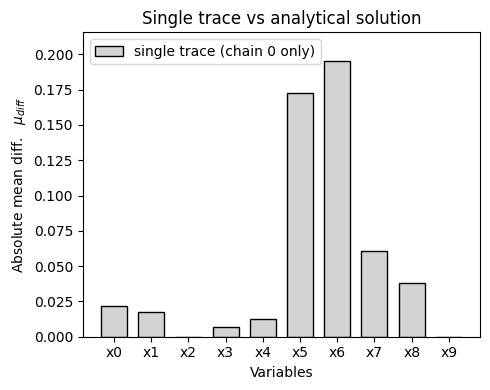

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# empirical probability from ONE CHAIN ONLY (to match your paper code)
def p_est_single_chain(trace, var_name, outcome):
    vals = trace.posterior.sel(chain=0)[var_name].values.reshape(-1)
    return np.mean(vals == outcome)

variables = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

for x in variables:
    if x in ['x0', 'x1']:
        outcomes = range(31)
    elif x == 'x2':
        outcomes = range(30, 31)
    elif x in ['x3', 'x4']:
        outcomes = range(30, 126)
    else:
        outcomes = range(2)

    x_conv = x if x in ['x0', 'x1', 'x2', 'x3', 'x4'] else 'g' + str(int(x[1]) - 5)

    err = np.mean([
        abs(p_est_single_chain(trace, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err)

df_single_trace = pd.DataFrame(data_single_trace)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

xpos = np.arange(len(df_single_trace))
ax.bar(
    xpos,
    df_single_trace['err_mean_mean'].values,
    color='lightgray',
    edgecolor='black',
    width=0.7,
    label='single trace (chain 0 only)'
)

ax.set_xticks(xpos, df_single_trace['var_name'].values, rotation=0)
ax.set_xlabel('Variables')
ax.set_ylabel(r'Absolute mean diff.   $\mu_{diff}$')
ax.set_title('Single trace vs analytical solution')
ax.legend(loc='upper left')
ax.set_ylim(0, df_single_trace['err_mean_mean'].max() + 0.02)

plt.tight_layout()
plt.show()

  var_name  err_mean_mean
0       x0       0.021864
1       x1       0.017329
2       x2       0.000000
3       x3       0.006994
4       x4       0.012255
5       x5       0.172440
6       x6       0.195573
7       x7       0.061041
8       x8       0.037907
9       x9       0.000000


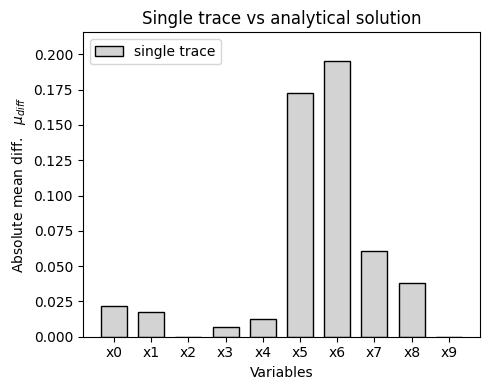

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def p_est_original_style(trace_chain0, var_name, outcome):
    return np.mean(trace_chain0[var_name] == outcome).item()

variables = ['x0','x1','x2','x3','x4','x5','x6','x7','x8','x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

trace_chain0 = trace.posterior.sel(chain=0)

for x in variables:
    ran = range(30, 31)
    if x in ['x0', 'x1']:
        ran = range(31)
    elif x in ['x3', 'x4']:
        ran = range(30, 126)
    elif x in ['x5', 'x6', 'x7', 'x8', 'x9']:
        ran = range(2)

    outcomes = ran
    x_conv = x if x in ['x0','x1','x2','x3','x4'] else 'g' + str(int(x[1]) - 5)

    err_outcome_mean = np.mean([
        np.abs(p_est_original_style(trace_chain0, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err_outcome_mean)

df_single_trace = pd.DataFrame(data_single_trace)
print(df_single_trace)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.bar(
    df_single_trace['var_name'],
    df_single_trace['err_mean_mean'],
    color='lightgray',
    edgecolor='black',
    width=0.7,
    label='single trace'
)
ax.set_xlabel('Variables')
ax.set_ylabel(r'Absolute mean diff.   $\mu_{diff}$')
ax.set_title('Single trace vs analytical solution')
ax.legend(loc='upper left')
ax.set_ylim(0, df_single_trace['err_mean_mean'].max() + 0.02)
plt.tight_layout()
plt.show()